In [1]:
# 1. Prerequisites

In [2]:
from utils.data import load_data, save_data
from utils.plotting import create_post_stim_raster_plot, map_colour_to_electrode

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import h5py
from tqdm import tqdm
from torch.utils.data import DataLoader, TensorDataset
import getpass

In [4]:
# Load the specific network here
Network = 5
DIV     = 21
group_data  = True
test_data = False

In [5]:
data = load_data(Network, DIV, group_data)
stimulation_parameters, stimulation_patterns, binned_spike_train_responses, stimulation_times, impedance_map, electrodes = data
print(f"Loaded data with response shape {binned_spike_train_responses.shape} and parameter shape {stimulation_parameters.shape}.")
if test_data:
    data = load_data(Network, DIV, group_data, test_mode=True)
    stimulation_parameters_test, stimulation_patterns_test, binned_spike_train_responses_test, stimulation_times_test, _, _ = data
else:
    binned_spike_train_responses_test = stimulation_patterns_test = stimulation_parameters_test = stimulation_times_test = None

Loaded data with response shape (35640, 160, 80) and parameter shape (35640, 2).


In [6]:
# 2. Model Definitions and Data Preparation

In [7]:
class CNN(nn.Module):
    """
    A simple CNN that takes an inputs of size (Batch, Channel, Height, Width). 
    The height in our task corresponds to the number of channels, the width to the number of time bins.
    """

    def __init__(self, n_outputs=1, n_base_channels= 32):
        super().__init__()

        self.convolutional_layers = nn.Sequential(
            nn.Conv2d(1, n_base_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(n_base_channels, n_base_channels*2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(n_base_channels*2, n_base_channels*4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # This function pools an arbitrary input size to a predefined size
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        # output layers
        self.fully_connected_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(n_base_channels * 4 * 4 * 4, n_base_channels*8),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(n_base_channels*8, n_outputs),
        )

    def forward(self, x):
        x = self.convolutional_layers(x)
        x = self.adaptive_pool(x) 
        x = self.fully_connected_layers(x)
        return x

In [8]:
# Hyperparameters
# This is how often the model sees the full training dataset.  
n_epochs = 50

# The number of samples used for a single update step. Usually it is common to put this to large values from 32-1024. 
# It should be compared with the number of total training samples, and larger values will use more GPU memory. 
batch_size = 256

# Update step size which will be combined with the gradients.
# Start higher for faster learning; the scheduler will reduce it when validation loss plateaus.
learning_rate = 3e-4

# Here we define the used loss function. In this case it is cross entropy. The reduction we apply within the loop.
criterion = nn.CrossEntropyLoss(reduction='none')

# At last, we intialize the model and an optimizer, where latter takes care of combining learning rate and gradients.
n_classes = 16 # This is given by the data
# A CNN expects an input of shape (Batch, Channel, Height, Width). We have to manually add the channel dimension to the data:
if binned_spike_train_responses.ndim != 4:
    print(f"Initial input data size is {binned_spike_train_responses.shape}")
    binned_spike_train_responses = binned_spike_train_responses[:,None]
    print(f"Adjusted input data size is {binned_spike_train_responses.shape}")
if binned_spike_train_responses_test is not None and binned_spike_train_responses_test.ndim != 4: 
    binned_spike_train_responses_test = binned_spike_train_responses_test[:,None]

model = CNN(n_classes, n_base_channels=32)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# Reduce the learning rate when the validation loss stops improving.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10
)

print(f"The model has {sum(p.numel() for p in model.parameters())} parameters.")

Initial input data size is (35640, 160, 80)
Adjusted input data size is (35640, 1, 160, 80)
The model has 621328 parameters.


In [9]:
# Data loading
# Pytorch dataloaders are parallel processing classes optimized for machine learning with Python. 
# It is recommended to use them. Here we set up such a dataloader. 
# We first split the training data into train and validation set. 

stimulation_patterns_one_hot = F.one_hot(
    torch.as_tensor(stimulation_patterns).long(),
    num_classes=n_classes
).float()

val_frac = 0.1
n_val = int(binned_spike_train_responses.shape[0] * val_frac)

idx = torch.randperm(binned_spike_train_responses.shape[0])
val_idx = idx[:n_val]
trn_idx = idx[n_val:]

# Here, Z is any additional information we want to keep with the dataset split. 
Xtr, Ytr, Ztr = (
    binned_spike_train_responses[trn_idx],
    stimulation_patterns_one_hot[trn_idx],
    stimulation_parameters[trn_idx],
)

Xval, Yval, Zval = (
    binned_spike_train_responses[val_idx],
    stimulation_patterns_one_hot[val_idx],
    stimulation_parameters[val_idx],
)

# Convert inputs to tensors
Xtr = torch.as_tensor(Xtr, dtype=torch.float32)
Xval = torch.as_tensor(Xval, dtype=torch.float32)

# Reduce skew in spike counts
Xtr = torch.log1p(Xtr)
Xval = torch.log1p(Xval)

# Normalize using TRAINING data statistics only
mean = Xtr.mean()
std = Xtr.std() + 1e-6

Xtr = (Xtr - mean) / std
Xval = (Xval - mean) / std

# Here we initialize the dataloaders. 
train_dataset = TensorDataset(
    Xtr,
    Ytr,
    torch.as_tensor(Ztr, dtype=torch.float32)
)

val_dataset = TensorDataset(
    Xval,
    Yval,
    torch.as_tensor(Zval, dtype=torch.float32)
)

# Through deletion we can free up memory from our system
del Xtr, Ytr, Ztr
del Xval, Yval
del binned_spike_train_responses, stimulation_parameters, stimulation_patterns

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

if binned_spike_train_responses_test is not None:
    Xtest = torch.as_tensor(
        binned_spike_train_responses_test,
        dtype=torch.float32
    )

    # Same preprocessing as train/validation
    Xtest = torch.log1p(Xtest)
    Xtest = (Xtest - mean) / std

    test_dataset = TensorDataset(Xtest)

    # Don't shuffle this data as else the predictions will be random w.r.t. the ground truth!
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    del Xtest
    del binned_spike_train_responses_test, stimulation_parameters_test, stimulation_patterns_test

else:
    test_loader = None

In [10]:
# 3. Training and Validation Loop

In [11]:
import os
import getpass
import torch
import numpy as np
from tqdm import tqdm

device = torch.device(
    "cuda:1" if torch.cuda.device_count() > 1
    else "cuda:0" if torch.cuda.is_available()
    else "cpu"
)

print(f"Running final task model on {device}.")
model.to(device)

# Save the final task model separately so it does NOT conflict with the example model
best_model_path = f"/home/{getpass.getuser()}/best_model_final_task_1.pth"

# Load previous all-time best final-task loss, if available
if os.path.exists(best_model_path):
    checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)

    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        all_time_best_val_loss = checkpoint.get("best_val_loss", float("inf"))
        print(f"Previous all-time best final-task validation loss: {all_time_best_val_loss:.4f}")
        print(f"Previous all-time best final-task epoch: {checkpoint.get('best_epoch', 'unknown')}")
        print(f"Previous all-time best final-task run: {checkpoint.get('run_name', 'unknown')}")
    else:
        all_time_best_val_loss = float("inf")
        print("Found old-format best_model_final_task_1.pth without validation-loss metadata.")
        print("This run may overwrite it because the previous best loss is unknown.")
else:
    all_time_best_val_loss = float("inf")
    print("No previous all-time best final-task model found.")

run_name = "final_task_1_run"

pbar = tqdm(range(n_epochs), leave=False)

train_losses = np.zeros(n_epochs)
validation_losses = dict()
validation_predictions = dict()

# Track best within this run too
current_run_best_val_loss = float("inf")
current_run_best_epoch = None

for epoch in pbar:
    model.train()
    train_loss = 0.0

    for x, y, z in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        pred = model(x)
        loss = torch.mean(criterion(pred, y))
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses[epoch] = train_loss

    model.eval()
    val_loss = []
    val_pred = []

    with torch.no_grad():
        for x, y, z in val_loader:
            x, y = x.to(device), y.to(device)

            pred = model(x)
            loss = criterion(pred, y)

            val_loss.append(loss.detach().cpu().numpy())
            val_pred.append(torch.argmax(pred, dim=-1).detach().cpu().numpy())

    val_loss = np.concatenate(val_loss)
    val_pred = np.concatenate(val_pred)

    avg_val_loss = float(np.mean(val_loss))

    # Update ReduceLROnPlateau scheduler using validation loss
    old_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(avg_val_loss)
    new_lr = optimizer.param_groups[0]["lr"]

    if new_lr != old_lr:
        print(f"\nLearning rate reduced: {old_lr:.2e} -> {new_lr:.2e}")

    epoch_number = epoch + 1
    validation_losses[f"epoch_{epoch_number}"] = val_loss
    validation_predictions[f"epoch_{epoch_number}"] = val_pred

    # Best within this run
    if avg_val_loss < current_run_best_val_loss:
        current_run_best_val_loss = avg_val_loss
        current_run_best_epoch = epoch_number

    # All-time best final-task model across runs
    if avg_val_loss < all_time_best_val_loss:
        all_time_best_val_loss = avg_val_loss

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_val_loss": all_time_best_val_loss,
                "best_epoch": epoch_number,
                "run_name": run_name,
                "n_epochs": n_epochs,
                "learning_rate": optimizer.param_groups[0]["lr"],
            },
            best_model_path,
        )

        print(
            f"\nNew all-time best final-task model saved: "
            f"epoch {epoch_number}, val loss {all_time_best_val_loss:.4f}"
        )

    pbar.set_postfix(
        loss_train=f"{train_loss:.4f}",
        loss_val=f"{avg_val_loss:.4f}",
        lr=f"{optimizer.param_groups[0]['lr']:.2e}",
        best_this_run=f"{current_run_best_val_loss:.4f}",
        best_all_time=f"{all_time_best_val_loss:.4f}",
    )

print(f"\nBest validation loss in this final-task run: {current_run_best_val_loss:.4f}")
print(f"Best epoch in this final-task run: {current_run_best_epoch}")
print(f"All-time best final-task validation loss after this run: {all_time_best_val_loss:.4f}")
print(f"Best final-task model path: {best_model_path}")

Running final task model on cuda:1.
Previous all-time best final-task validation loss: 1.5658
Previous all-time best final-task epoch: 48
Previous all-time best final-task run: final_task_1_run


 84%|████████▍ | 42/50 [15:29<02:53, 21.73s/it, best_all_time=1.5650, best_this_run=1.5650, loss_train=1.5496, loss_val=1.5650, lr=3.00e-04]


New all-time best final-task model saved: epoch 42, val loss 1.5650


 88%|████████▊ | 44/50 [16:12<02:10, 21.73s/it, best_all_time=1.5620, best_this_run=1.5620, loss_train=1.5399, loss_val=1.5620, lr=3.00e-04]


New all-time best final-task model saved: epoch 44, val loss 1.5620


 90%|█████████ | 45/50 [16:34<01:48, 21.73s/it, best_all_time=1.5563, best_this_run=1.5563, loss_train=1.5427, loss_val=1.5563, lr=3.00e-04]


New all-time best final-task model saved: epoch 45, val loss 1.5563


 96%|█████████▌| 48/50 [17:39<00:43, 21.73s/it, best_all_time=1.5559, best_this_run=1.5559, loss_train=1.5178, loss_val=1.5559, lr=3.00e-04]


New all-time best final-task model saved: epoch 48, val loss 1.5559



New all-time best final-task model saved: epoch 50, val loss 1.5558

Best validation loss in this final-task run: 1.5558
Best epoch in this final-task run: 50
All-time best final-task validation loss after this run: 1.5558
Best final-task model path: /home/bnn_10fs26/best_model_final_task_1.pth


In [12]:
# 4. Benchmarking

Benchmarking recent final-task run
Best epoch in recent run: 50
Best validation loss in recent run: 1.5558
Overall validation accuracy using best epoch from recent final-task run: 34.01%


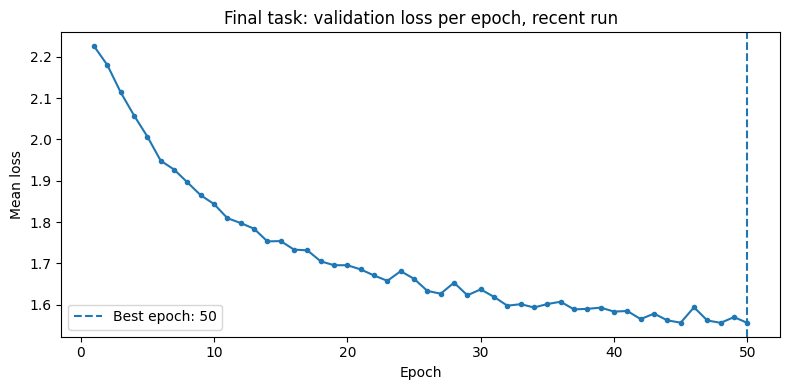

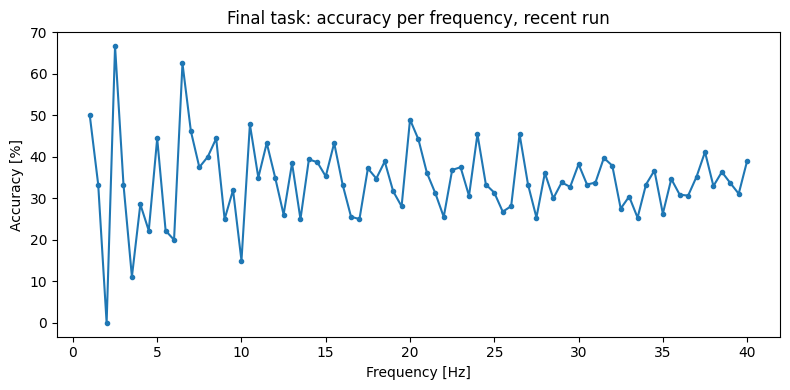

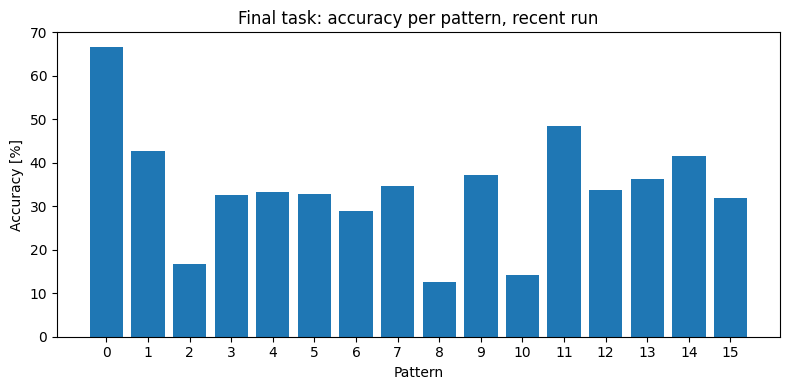

In [13]:
# Benchmarking: best epoch from the most recent final-task run

import numpy as np
import matplotlib.pyplot as plt

if "validation_losses" not in globals() or len(validation_losses) == 0:
    raise RuntimeError("No validation_losses found. Run the training cell first.")

if "validation_predictions" not in globals() or len(validation_predictions) == 0:
    raise RuntimeError("No validation_predictions found. Run the training cell first.")

# Find best validation-loss epoch from this run
val_keys = sorted(validation_losses.keys(), key=lambda x: int(x.split("_")[1]))
val_epochs = [int(k.split("_")[1]) for k in val_keys]
epoch_losses = [np.mean(validation_losses[k]) for k in val_keys]

best_epoch_key = min(
    validation_losses.keys(),
    key=lambda k: np.mean(validation_losses[k])
)

best_epoch = int(best_epoch_key.split("_")[1])
best_val_loss = np.mean(validation_losses[best_epoch_key])

print("Benchmarking recent final-task run")
print(f"Best epoch in recent run: {best_epoch}")
print(f"Best validation loss in recent run: {best_val_loss:.4f}")

# Accuracy from stored predictions of the best recent epoch
predictions = np.array(validation_predictions[best_epoch_key])
true_labels = Zval[:, 1]

accuracy = predictions == true_labels
overall_acc = accuracy.mean() * 100

print(f"Overall validation accuracy using best epoch from recent final-task run: {overall_acc:.2f}%")

# Plot validation loss across epochs
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(val_epochs, epoch_losses, marker="o", markersize=3)
ax.axvline(best_epoch, linestyle="--", label=f"Best epoch: {best_epoch}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean loss")
ax.set_title("Final task: validation loss per epoch, recent run")
ax.legend()
fig.tight_layout()
plt.show()

# Accuracy per frequency
frequencies = Zval[:, 0]
unique_freqs = np.unique(frequencies)

frequency_accuracies = np.array([
    accuracy[frequencies == f].mean() * 100
    for f in unique_freqs
])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(unique_freqs, frequency_accuracies, marker="o", markersize=3)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Accuracy [%]")
ax.set_title("Final task: accuracy per frequency, recent run")
fig.tight_layout()
plt.show()

# Accuracy per pattern across all frequencies
patterns = Zval[:, 1]
unique_patterns = np.unique(patterns)

pattern_accuracies = np.array([
    accuracy[patterns == p].mean() * 100
    for p in unique_patterns
])

x = np.arange(len(unique_patterns))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x, pattern_accuracies)
ax.set_xticks(x)
ax.set_xticklabels(unique_patterns.astype(int).astype(str))
ax.set_xlabel("Pattern")
ax.set_ylabel("Accuracy [%]")
ax.set_title("Final task: accuracy per pattern, recent run")
fig.tight_layout()
plt.show()

Benchmarking all-time best final-task model on cuda:1.
Loaded all-time best final-task checkpoint
Best validation loss: 1.5557996034622192
Best epoch: 50
Run name: final_task_1_run
Overall validation accuracy using all-time best final-task model: 34.01%


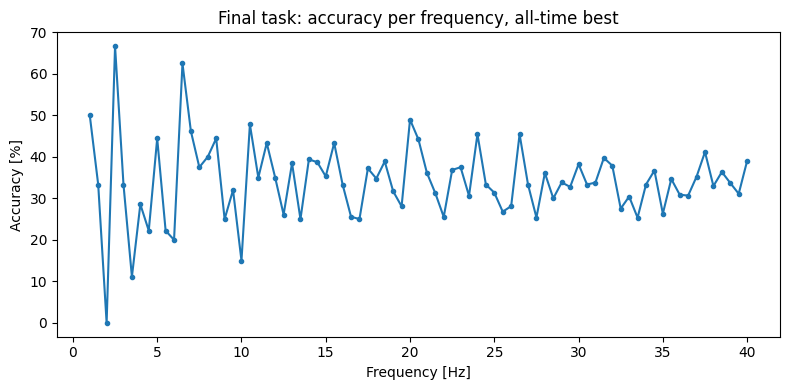

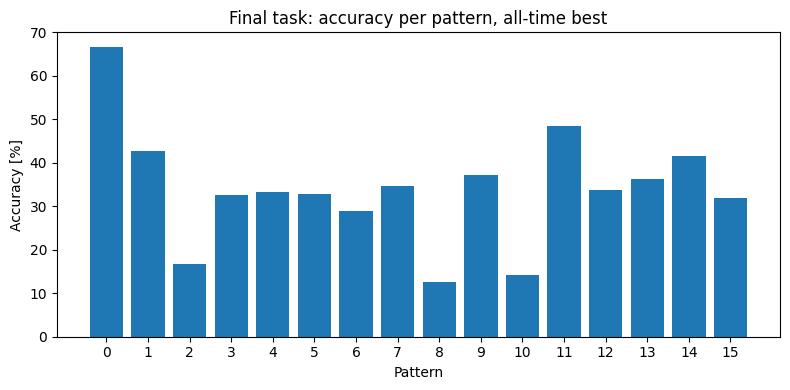

In [14]:
# Benchmarking: all-time best final-task model

import os
import getpass
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device(
    "cuda:1" if torch.cuda.device_count() > 1
    else "cuda:0" if torch.cuda.is_available()
    else "cpu"
)

print(f"Benchmarking all-time best final-task model on {device}.")

best_model_path = f"/home/{getpass.getuser()}/best_model_final_task_1.pth"

if not os.path.exists(best_model_path):
    raise FileNotFoundError(f"No saved best final-task model found at: {best_model_path}")

checkpoint = torch.load(best_model_path, map_location=device, weights_only=False)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])

    print("Loaded all-time best final-task checkpoint")
    print("Best validation loss:", checkpoint.get("best_val_loss", "unknown"))
    print("Best epoch:", checkpoint.get("best_epoch", "unknown"))
    print("Run name:", checkpoint.get("run_name", "unknown"))
else:
    model.load_state_dict(checkpoint)
    print("Loaded old-format final-task model state_dict.")
    print("Warning: no best_val_loss metadata available.")

model.to(device)
model.eval()

# Recompute validation predictions with loaded all-time best model
all_preds = []

with torch.no_grad():
    for x, y, z in val_loader:
        x = x.to(device)

        pred = model(x)
        pred_class = torch.argmax(pred, dim=-1)

        all_preds.append(pred_class.detach().cpu().numpy())

all_preds = np.concatenate(all_preds)

true_labels = Zval[:, 1]
accuracy = all_preds == true_labels
overall_acc = accuracy.mean() * 100

print(f"Overall validation accuracy using all-time best final-task model: {overall_acc:.2f}%")

# Accuracy per frequency
frequencies = Zval[:, 0]
unique_freqs = np.unique(frequencies)

frequency_accuracies = np.array([
    accuracy[frequencies == f].mean() * 100
    for f in unique_freqs
])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(unique_freqs, frequency_accuracies, marker="o", markersize=3)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Accuracy [%]")
ax.set_title("Final task: accuracy per frequency, all-time best")
fig.tight_layout()
plt.show()

# Accuracy per pattern across all frequencies
patterns = Zval[:, 1]
unique_patterns = np.unique(patterns)

pattern_accuracies = np.array([
    accuracy[patterns == p].mean() * 100
    for p in unique_patterns
])

x = np.arange(len(unique_patterns))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x, pattern_accuracies)
ax.set_xticks(x)
ax.set_xticklabels(unique_patterns.astype(int).astype(str))
ax.set_xlabel("Pattern")
ax.set_ylabel("Accuracy [%]")
ax.set_title("Final task: accuracy per pattern, all-time best")
fig.tight_layout()
plt.show()